In [1]:
# Imports 
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from PIL import Image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

In [2]:
warnings.filterwarnings('ignore')

In [3]:
# Define Dataset Paths:
DATA_DIR = "chest_xray"

TRAIN_DIR = "chest_xray/train"
VAL_DIR = "chest_xray/val"
TEST_DIR = "chest_xray/test"

In [4]:
# Verify Dataset Categories:
print("Training Categories:")
print(os.listdir(TRAIN_DIR))

print("\nValidation Categories:")
print(os.listdir(VAL_DIR))

print("\nTest Categories:")
print(os.listdir(TEST_DIR))

Training Categories:
['PNEUMONIA', 'NORMAL']

Validation Categories:
['PNEUMONIA', 'NORMAL']

Test Categories:
['PNEUMONIA', 'NORMAL']


In [5]:
# Count Images in each category:
train_normal = len(os.listdir(TRAIN_DIR + "/NORMAL"))
train_pneumonia = len(os.listdir(TRAIN_DIR + "/PNEUMONIA"))

val_normal = len(os.listdir(VAL_DIR + "/NORMAL"))
val_pneumonia = len(os.listdir(VAL_DIR + "/PNEUMONIA"))

test_normal = len(os.listdir(TEST_DIR + "/NORMAL"))
test_pneumonia = len(os.listdir(TEST_DIR + "/PNEUMONIA"))

print("Training Set:")
print("NORMAL:", train_normal)
print("PNEUMONIA:", train_pneumonia)

print("\nValidation Set:")
print("NORMAL:", val_normal)
print("PNEUMONIA:", val_pneumonia)

print("\nTest Set:")
print("NORMAL:", test_normal)
print("PNEUMONIA:", test_pneumonia)

Training Set:
NORMAL: 1341
PNEUMONIA: 3875

Validation Set:
NORMAL: 8
PNEUMONIA: 8

Test Set:
NORMAL: 234
PNEUMONIA: 390


In [6]:
# Create Dataset - Count Summary:
count_data = {
    "Dataset": ["Train", "Train","Validation", "Validation", "Test", "Test"],
    "Class": ["Normal", "Pneumonia", "Normal", "Pneumonia", "Normal", "Pneumonia"],
    "Image Count": [
        train_normal, train_pneumonia,
        val_normal, val_pneumonia,
        test_normal, test_pneumonia
    ]
}

count_df = pd.DataFrame(count_data)
count_df

,Dataset,Class,Image Count
0,Train,Normal,1341
1,Train,Pneumonia,3875
2,Validation,Normal,8
3,Validation,Pneumonia,8
4,Test,Normal,234
5,Test,Pneumonia,390


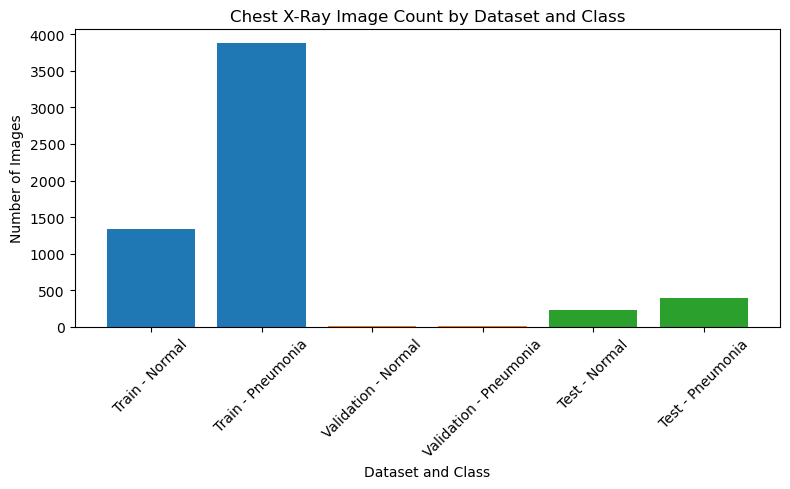

In [7]:
# Visualize Class Distribution:
plt.figure(figsize=(8, 5))

for dataset in count_df["Dataset"].unique():
    subset = count_df[count_df["Dataset"] == dataset]
    plt.bar(
        subset["Dataset"] + " - " + subset["Class"],
        subset["Image Count"]
    )
plt.title("Chest X-Ray Image Count by Dataset and Class")
plt.xlabel("Dataset and Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## Image Exploration:

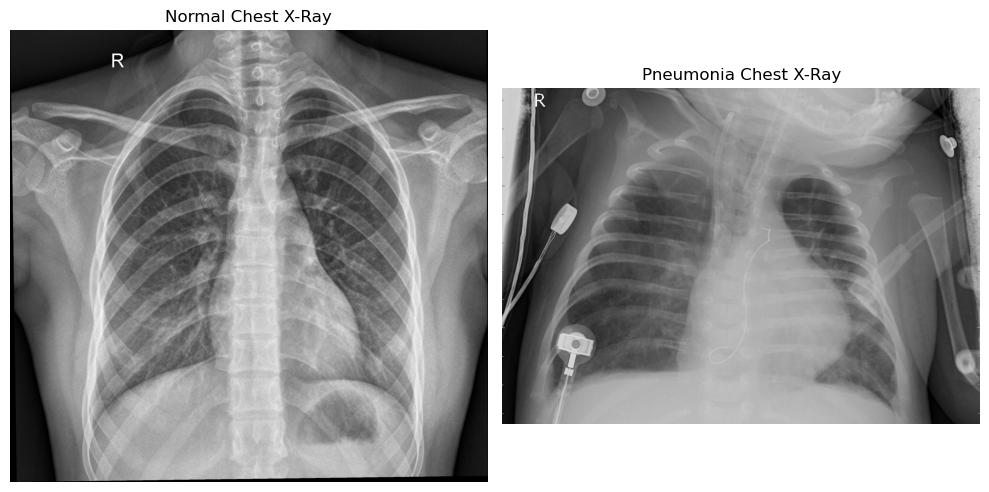

In [8]:
# Display Sample Images:
normal_path = TRAIN_DIR + "/NORMAL"
pneumonia_path = TRAIN_DIR + "/PNEUMONIA"
normal_images = os.listdir(normal_path)
pneumonia_images = os.listdir(pneumonia_path)

plt.figure(figsize=(10, 5))

# Display Normal Image
normal_img = Image.open(normal_path + "/" + normal_images[0])
plt.subplot(1, 2, 1)
plt.imshow(normal_img, cmap="gray")
plt.title("Normal Chest X-Ray")
plt.axis("off")

# Display Pneumonia Image
pneumonia_img = Image.open(pneumonia_path + "/" + pneumonia_images[0])
plt.subplot(1, 2, 2)
plt.imshow(pneumonia_img, cmap="gray")
plt.title("Pneumonia Chest X-Ray")
plt.axis("off")

plt.tight_layout()
plt.show()

In [9]:
# Image Processing and Data Generators:
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(rescale=1./225)
val_test_datagen = ImageDataGenerator(rescale=1./225)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

val_generator = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

# Verify Class Labels:
print("\nClass indices:", train_generator.class_indices)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.

Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}


In [10]:
# Build Baseline CNN Model:
model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    MaxPooling2D(2, 2),
    
    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D(2, 2),

    Flatten(),

    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(1, activation="sigmoid")
])

In [11]:
# Compile CNN
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]

)

# Train CNN
EPOCHS = 5
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS
)

Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 85s 519ms/step - accuracy: 0.8048 - loss: 0.4916 - val_accuracy: 0.6875 - val_loss: 1.0672
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 69s 422ms/step - accuracy: 0.9503 - loss: 0.1332 - val_accuracy: 0.8125 - val_loss: 0.4104
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 60s 365ms/step - accuracy: 0.9710 - loss: 0.0830 - val_accuracy: 0.8750 - val_loss: 0.2537
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 59s 364ms/step - accuracy: 0.9714 - loss: 0.0785 - val_accuracy: 0.6875 - val_loss: 0.7773
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 61s 371ms/step - accuracy: 0.9789 - loss: 0.0554 - val_accuracy: 0.6875 - val_loss: 0.7742


In [12]:
# Evaluate Model on Test Data:
test_loss, test_accuracy = model.evaluate(test_generator)
print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 143ms/step - accuracy: 0.4503 - loss: 2.3456
Test Accuracy: 0.7035256624221802
Test Loss: 1.2875630855560303


In [13]:
# Generate Predictions on Test Data:
predictions = model.predict(test_generator)
predicted_classes = (predictions > 0.5).astype("int32")
true_classes = test_generator.classes

print("Prediction Shape:", predictions.shape)
print("Predicted Classes Shape:", predicted_classes.shape)

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 169ms/step
Prediction Shape: (624, 1)
Predicted Classes Shape: (624, 1)


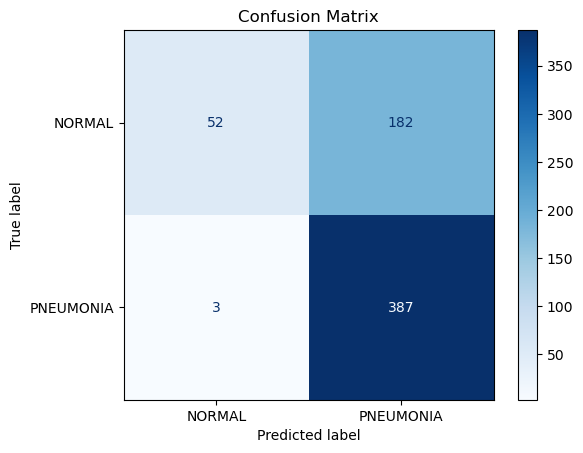

In [14]:
# Create Confusion Matrix:
cm = confusion_matrix(true_classes, predicted_classes)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["NORMAL", "PNEUMONIA"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [15]:
# Classification Report:
print(classification_report(
    true_classes,
    predicted_classes,
    target_names=["NORMAL", "PNEUMONIA"]
))

              precision    recall  f1-score   support

      NORMAL       0.95      0.22      0.36       234
   PNEUMONIA       0.68      0.99      0.81       390

    accuracy                           0.70       624
   macro avg       0.81      0.61      0.58       624
weighted avg       0.78      0.70      0.64       624



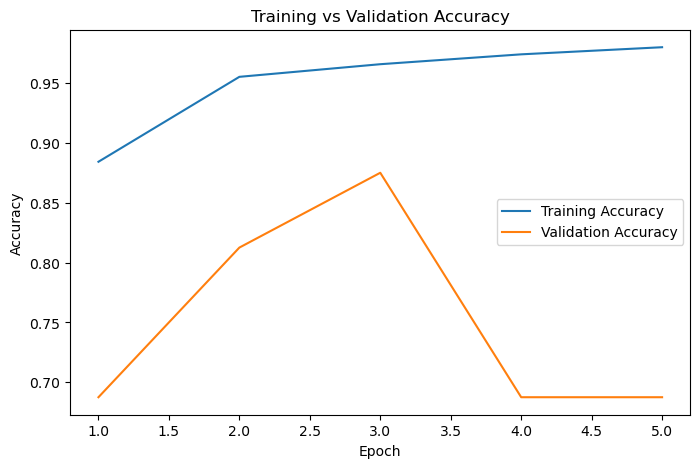

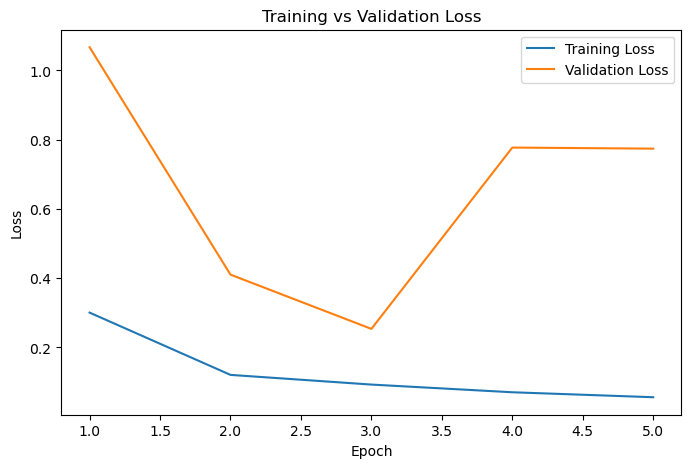

In [16]:
# Plot Accuracy and Loss Curves:
train_accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]

train_loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs_range = range(1, EPOCHS + 1)

# Accuracy Plot
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_accuracy, label="Training Accuracy")
plt.plot(epochs_range, val_accuracy, label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

# Loss Plot
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

### Transfer Learning Model:

In [17]:
# Build Transfer Learning Model:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
)

base_model.trainable = False

x = base_model.output
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(1, activation="sigmoid")(x)

transfer_model = Model(inputs=base_model.input, outputs=output)

In [18]:
# Compile Transfer Learning Model:
transfer_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [19]:
# Train Transfer Learning Model:
TRANSFER_EPOCHS = 5

transfer_history = transfer_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=TRANSFER_EPOCHS
)

Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 36s 212ms/step - accuracy: 0.9025 - loss: 0.2229 - val_accuracy: 0.7500 - val_loss: 0.4470
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 33s 203ms/step - accuracy: 0.9675 - loss: 0.0957 - val_accuracy: 0.8750 - val_loss: 0.4430
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 34s 206ms/step - accuracy: 0.9681 - loss: 0.0800 - val_accuracy: 0.8750 - val_loss: 0.3112
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 34s 206ms/step - accuracy: 0.9782 - loss: 0.0723 - val_accuracy: 1.0000 - val_loss: 0.0915
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 33s 205ms/step - accuracy: 0.9738 - loss: 0.0708 - val_accuracy: 0.8125 - val_loss: 0.4615


In [20]:
# Evaluate on Test Data:
transfer_test_loss, transfer_test_accuracy = transfer_model.evaluate(test_generator)

print("Transfer Learning Test Accuracy:", transfer_test_accuracy)
print("Transfer Learning Test Loss:", transfer_test_loss)

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 193ms/step - accuracy: 0.6164 - loss: 1.3846
Transfer Learning Test Accuracy: 0.7772436141967773
Transfer Learning Test Loss: 0.8264997601509094


In [21]:
# Generate Predictions:
transfer_predictions = transfer_model.predict(test_generator)
transfer_predicted_classes = (transfer_predictions > 0.5).astype("int32")

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 208ms/step


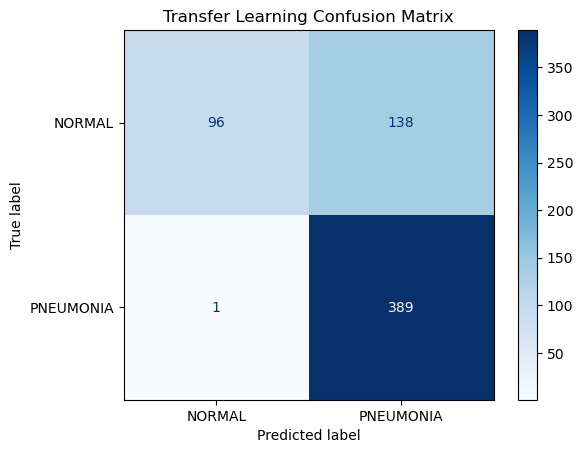

In [22]:
# Create Confusion Matrix:
transfer_cm = confusion_matrix(true_classes, transfer_predicted_classes)

transfer_disp = ConfusionMatrixDisplay(
    confusion_matrix=transfer_cm,
    display_labels=["NORMAL", "PNEUMONIA"]
)

transfer_disp.plot(cmap="Blues")

plt.title("Transfer Learning Confusion Matrix")
plt.show()

In [23]:
# Classification Report:
print(classification_report(
    true_classes,
    transfer_predicted_classes,
    target_names=["NORMAL", "PNEUMONIA"]
))

              precision    recall  f1-score   support

      NORMAL       0.99      0.41      0.58       234
   PNEUMONIA       0.74      1.00      0.85       390

    accuracy                           0.78       624
   macro avg       0.86      0.70      0.71       624
weighted avg       0.83      0.78      0.75       624

